IMPORT LIBRARIES

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.inspection import permutation_importance

# Jika belum terinstal imblearn (SMOTE), install:
try:
    from imblearn.over_sampling import SMOTE
except Exception:
    !pip install -q imbalanced-learn
    from imblearn.over_sampling import SMOTE

In [7]:
df = pd.read_csv('/content/drive/MyDrive/dataset_AI/data-bank.csv')
df.head()

,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,1,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,...,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,1,0.016469
1,1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,...,0.795297,0.008323,0.623652,0.610237,0.839969,0.283846,0.264577,0.570175,1,0.020794
2,1,0.426071,0.499019,0.472295,0.601450,0.601364,0.998857,0.796403,0.808388,0.302035,...,0.774670,0.040003,0.623841,0.601449,0.836774,0.290189,0.026555,0.563706,1,0.016474
3,1,0.399844,0.451265,0.457733,0.583541,0.583541,0.998700,0.796967,0.808966,0.303350,...,0.739555,0.003252,0.622929,0.583538,0.834697,0.281721,0.026697,0.564663,1,0.023982
4,1,0.465022,0.538432,0.522298,0.598783,0.598783,0.998973,0.797366,0.809304,0.303475,...,0.795016,0.003878,0.623521,0.598782,0.839973,0.278514,0.024752,0.575617,1,0.035490


In [8]:
# 3) CLEAN COLUMN NAMES (penting: menghilangkan spasi & tanda tanya)
df.columns = (df.columns
              .str.strip()                        # hapus spasi di ujung
              .str.replace(' ', '_', regex=False) # spasi -> underscore
              .str.replace(r'[^0-9a-zA-Z_]', '', regex=True)  # hapus simbol (termasuk '?')
              .str.lower())                       # lower-case

print("Kolom setelah bersih (sample):", df.columns[:12].tolist())

Kolom setelah bersih (sample): ['bankrupt', 'roac_before_interest_and_depreciation_before_interest', 'roaa_before_interest_and__after_tax', 'roab_before_interest_and_depreciation_after_tax', 'operating_gross_margin', 'realized_sales_gross_margin', 'operating_profit_rate', 'pretax_net_interest_rate', 'aftertax_net_interest_rate', 'nonindustry_income_and_expenditurerevenue', 'continuous_interest_rate_after_tax', 'operating_expense_rate']


In [9]:
# 4) Tentukan target variable
# Berdasarkan file asli kolom target adalah "Bankrupt?" -> setelah cleaning jadi "bankrupt"
target = 'bankrupt'
if target not in df.columns:
    raise KeyError(f"Kolom target '{target}' tidak ditemukan di dataset. Kolom tersedia: {list(df.columns)[:30]}")

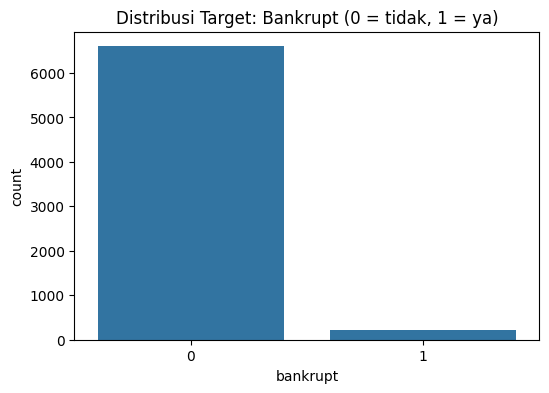


Proporsi kelas:
bankrupt
0    0.967737
1    0.032263
Name: proportion, dtype: float64


In [10]:
# 5) Exploratory Data Analysis (EDA) - Distribusi target
plt.figure(figsize=(6,4))
sns.countplot(x=target, data=df)
plt.title("Distribusi Target: Bankrupt (0 = tidak, 1 = ya)")
plt.show()

print("\nProporsi kelas:")
print(df[target].value_counts(normalize=True))

In [11]:
# 6) Quick info & missing values
print("\nInfo singkat:")
display(df.info())
print("\nMissing per kolom (top 10):")
print(df.isnull().sum().sort_values(ascending=False).head(10))


Info singkat:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6819 entries, 0 to 6818
Data columns (total 96 columns):
 #   Column                                                 Non-Null Count  Dtype  
---  ------                                                 --------------  -----  
 0   bankrupt                                               6819 non-null   int64  
 1   roac_before_interest_and_depreciation_before_interest  6819 non-null   float64
 2   roaa_before_interest_and__after_tax                    6819 non-null   float64
 3   roab_before_interest_and_depreciation_after_tax        6819 non-null   float64
 4   operating_gross_margin                                 6819 non-null   float64
 5   realized_sales_gross_margin                            6819 non-null   float64
 6   operating_profit_rate                                  6819 non-null   float64
 7   pretax_net_interest_rate                               6819 non-null   float64
 8   aftertax_net_interest_rate       

None


Missing per kolom (top 10):
bankrupt                                                 0
roac_before_interest_and_depreciation_before_interest    0
roaa_before_interest_and__after_tax                      0
roab_before_interest_and_depreciation_after_tax          0
operating_gross_margin                                   0
realized_sales_gross_margin                              0
operating_profit_rate                                    0
pretax_net_interest_rate                                 0
aftertax_net_interest_rate                               0
nonindustry_income_and_expenditurerevenue                0
dtype: int64


In [12]:
# 7) Drop kolom non-numeric atau identifier bila perlu
# Di dataset ini hampir seluruh kolom numeric; jika ada kolom string, drop/encode:
non_numeric = df.select_dtypes(include=['object']).columns.tolist()
print("Non-numeric columns:", non_numeric)
# Jika ada kolom non-numeric yang tidak dibutuhkan, drop. Contoh:
# df = df.drop(columns=['some_id_col'])

Non-numeric columns: []


In [13]:
# 8) Feature & target split
X = df.drop(columns=[target])
y = df[target].astype(int)

In [15]:
# 9) Handle missing values: drop kolom yang >50% missing, imputasi median untuk sisanya
thresh = 0.5 * X.shape[0]
cols_before = X.shape[1]
X = X.loc[:, X.isnull().sum() < thresh]
cols_after = X.shape[1]
print(f"Dropped {cols_before - cols_after} kolom karena banyak missing (>50%).")

# Impute numeric columns with median
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
imputer = SimpleImputer(strategy='median')
X[num_cols] = imputer.fit_transform(X[num_cols])

# Jika masih ada non-numeric columns (categorical), encode them:
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
if cat_cols:
    X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

Dropped 0 kolom karena banyak missing (>50%).


In [16]:
# 10) Train-test split (stratify karena imbalance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)


Train shape: (5455, 95) Test shape: (1364, 95)


In [17]:
# 11) Scaling - StandardScaler (fit on train)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [19]:
# 12) Tangani imbalance: cek proporsi, lalu gunakan SMOTE pada training set
from collections import Counter
from imblearn.over_sampling import SMOTE

print("Before SMOTE:", Counter(y_train))

# SMOTE tidak lagi mendukung n_jobs → hapus saja
sm = SMOTE(random_state=42)

X_train_res, y_train_res = sm.fit_resample(X_train_scaled, y_train)

print("After SMOTE:", Counter(y_train_res))


Before SMOTE: Counter({0: 5279, 1: 176})
After SMOTE: Counter({0: 5279, 1: 5279})


In [20]:
# 13) MODELLING - 3 model: Decision Tree, Random Forest, MLP (ANN)
# a) Decision Tree (default)
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_res, y_train_res)
y_pred_dt = dt.predict(X_test_scaled)
print("Decision Tree")
print(classification_report(y_test, y_pred_dt))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_dt))

Decision Tree
              precision    recall  f1-score   support

           0       0.98      0.96      0.97      1320
           1       0.26      0.45      0.33        44

    accuracy                           0.94      1364
   macro avg       0.62      0.71      0.65      1364
weighted avg       0.96      0.94      0.95      1364

Confusion matrix:
 [[1263   57]
 [  24   20]]


In [21]:
# b) Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train_res, y_train_res)
y_pred_rf = rf.predict(X_test_scaled)
y_pred_rf_proba = rf.predict_proba(X_test_scaled)[:,1]
print("Random Forest")
print(classification_report(y_test, y_pred_rf))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("ROC AUC (RF):", roc_auc_score(y_test, y_pred_rf_proba))

Random Forest
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      1320
           1       0.43      0.61      0.50        44

    accuracy                           0.96      1364
   macro avg       0.71      0.79      0.74      1364
weighted avg       0.97      0.96      0.96      1364

Confusion matrix:
 [[1284   36]
 [  17   27]]
ROC AUC (RF): 0.9429407713498623


In [22]:
# c) Artificial Neural Network (MLPClassifier)
mlp = MLPClassifier(hidden_layer_sizes=(64,32), max_iter=500, random_state=42)
mlp.fit(X_train_res, y_train_res)
y_pred_mlp = mlp.predict(X_test_scaled)
y_pred_mlp_proba = mlp.predict_proba(X_test_scaled)[:,1]
print("MLP (ANN)")
print(classification_report(y_test, y_pred_mlp))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_mlp))
print("ROC AUC (MLP):", roc_auc_score(y_test, y_pred_mlp_proba))

MLP (ANN)
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1320
           1       0.40      0.39      0.40        44

    accuracy                           0.96      1364
   macro avg       0.69      0.68      0.69      1364
weighted avg       0.96      0.96      0.96      1364

Confusion matrix:
 [[1295   25]
 [  27   17]]
ROC AUC (MLP): 0.8208333333333333


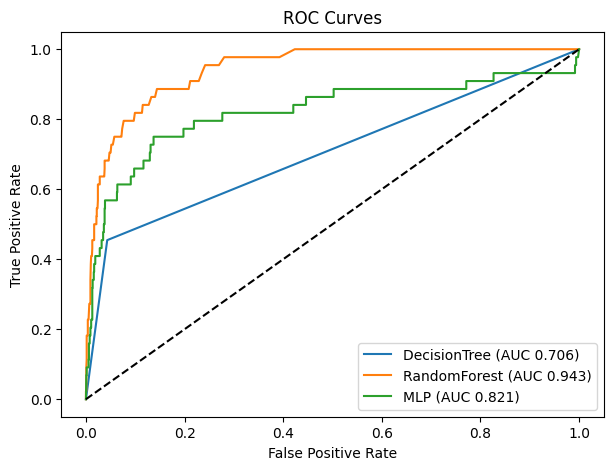

In [23]:
# 14) Plot ROC curves untuk perbandingan
fpr_dt, tpr_dt, _ = roc_curve(y_test, dt.predict_proba(X_test_scaled)[:,1])
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_rf_proba)
fpr_mlp, tpr_mlp, _ = roc_curve(y_test, y_pred_mlp_proba)

plt.figure(figsize=(7,5))
plt.plot(fpr_dt, tpr_dt, label=f"DecisionTree (AUC {roc_auc_score(y_test, dt.predict_proba(X_test_scaled)[:,1]):.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"RandomForest (AUC {roc_auc_score(y_test, y_pred_rf_proba):.3f})")
plt.plot(fpr_mlp, tpr_mlp, label=f"MLP (AUC {roc_auc_score(y_test, y_pred_mlp_proba):.3f})")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.show()


In [24]:
# 15) Feature importance (Random Forest) - ambil top 5
feat_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print("Top 10 fitur menurut Random Forest:")
print(feat_imp.head(10))

top5_rf = feat_imp.head(5)
print("\nTop 5 fitur paling mempengaruhi kebangkrutan (RF):")
for i, (feat, val) in enumerate(top5_rf.items(), start=1):
    print(f"{i}. {feat} (importance = {val:.4f})")

Top 10 fitur menurut Random Forest:
borrowing_dependency                       0.080414
net_income_to_total_assets                 0.050548
persistent_eps_in_the_last_four_seasons    0.042934
aftertax_net_interest_rate                 0.040194
liability_to_equity                        0.034355
debt_ratio_                                0.034129
net_worthassets                            0.034006
continuous_interest_rate_after_tax         0.032200
total_incometotal_expense                  0.026561
interest_expense_ratio                     0.026181
dtype: float64

Top 5 fitur paling mempengaruhi kebangkrutan (RF):
1. borrowing_dependency (importance = 0.0804)
2. net_income_to_total_assets (importance = 0.0505)
3. persistent_eps_in_the_last_four_seasons (importance = 0.0429)
4. aftertax_net_interest_rate (importance = 0.0402)
5. liability_to_equity (importance = 0.0344)


In [25]:
# 16) Alternatif: Permutation importance (lebih adil, bekerja juga untuk MLP)
perm_res = permutation_importance(rf, X_test_scaled, y_test, n_repeats=10, random_state=42, n_jobs=-1)
perm_imp = pd.Series(perm_res.importances_mean, index=X.columns).sort_values(ascending=False)
print("\nTop 5 fitur menurut Permutation Importance:")
print(perm_imp.head(5))


Top 5 fitur menurut Permutation Importance:
research_and_development_expense_rate    0.001540
current_liabilitiesliability             0.001026
inventoryworking_capital                 0.001026
contingent_liabilitiesnet_worth          0.000880
total_incometotal_expense                0.000587
dtype: float64


In [26]:
# 17) Simpan model (opsional)
import joblib
joblib.dump(rf, "random_forest_bankrupt_model.joblib")
joblib.dump(scaler, "scaler.joblib")
print("Model dan scaler disimpan: random_forest_bankrupt_model.joblib, scaler.joblib")

Model dan scaler disimpan: random_forest_bankrupt_model.joblib, scaler.joblib
